In [65]:
import scanpy as sc
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import joblib


In [66]:
home = "/project/Wellcome_Discovery/lturiano/GENESIS/"
data = "/project/Wellcome_Discovery/datashare/lturiano/data/"
sriva = "/project/Wellcome_Discovery/datashare/sriva/GENESIS/"

In [67]:
np.random.seed(42)

In [68]:
rna  = sc.read_h5ad(data+"rna_filt_aligned.h5ad")
gex  = sc.read_h5ad(data+"gex_filt_aligned.h5ad")

In [69]:
fake = sc.read_h5ad(data+"fake_PermInv_VAE_UNET.h5ad")

In [ ]:
# Load genes and label encoder from meta.joblib
meta = joblib.load(home + "02_weights/top10_xgb_meta.joblib")
genes = meta["genes"]

label_encoder = LabelEncoder()
label_encoder.classes_ = meta["label_classes"]   # must match training

FileNotFoundError: [Errno 2] No such file or directory: '/project/Wellcome_Discovery/lturiano/GENESIS/02_weigths/top10_xgb_meta.joblib'

In [ ]:
len(genes)

86

In [ ]:
label_encoder.classes_

array(['T cell', 'dendritic cell', 'duct cell', 'endothelial cell',
       'epithelial cell', 'fibroblast', 'lymphocyte', 'macrophage',
       'mural cell', 'myeloid cell', 'myocyte', 'neural cell'],
      dtype='<U16')

In [ ]:
df_rna = pd.DataFrame(index   = rna.obs.index,
                      columns = genes,
                      data    = rna.X[:, rna.var_names.isin(genes)])

df_gex = pd.DataFrame(index   = gex.obs.index,
                      columns = genes,
                      data    = gex.X[:, gex.var_names.isin(genes)])

df_fake = pd.DataFrame(index   = fake.obs.index,
                       columns = genes,
                       data    = fake.X[:, fake.var_names.isin(genes)])

In [ ]:
df_rna["cell_type"]  = label_encoder.transform(rna.obs["cell_type"].values.tolist())
df_gex["cell_type"]  = label_encoder.transform(gex.obs["cell_type"].values.tolist())
df_fake["cell_type"] = label_encoder.transform(rna.obs["cell_type"].values.tolist())

In [ ]:
# Create train-test split (final evaluation set)
X_train_rna, X_test_rna, y_train_rna, y_test_rna = train_test_split(df_rna[df_rna.columns[:-1]],
                                                                    df_rna[df_rna.columns[-1]],
                                                                    test_size=0.15,
                                                                    random_state=42,
                                                                    stratify=df_rna[df_rna.columns[-1]]
                                                                    )

In [ ]:
# Create train-test split (final evaluation set)
X_train_gex, X_test_gex, y_train_gex, y_test_gex = train_test_split(df_gex[df_gex.columns[:-1]],
                                                                    df_gex[df_gex.columns[-1]],
                                                                    test_size=0.15,
                                                                    random_state=42,
                                                                    stratify=df_gex[df_gex.columns[-1]]
                                                                    )

In [ ]:
# Create train-test split (final evaluation set)
X_train_fake, X_test_fake, y_train_fake, y_test_fake = train_test_split(df_fake[df_fake.columns[:-1]],
                                                                        df_fake[df_fake.columns[-1]],
                                                                        test_size=0.15,
                                                                        random_state=42,
                                                                        stratify=df_fake[df_fake.columns[-1]]
                                                                        )

# Performance evaluation on scRNA, scGEX, generated scGEX

In [ ]:
# Load the trained XGBoost model
model_rna = xgb.XGBClassifier()
model_rna.load_model(home + "02_weights/top10_xgb.json")

In [ ]:
# y_pred_rna = model_rna.predict(X_train_rna)
# print(f'Accuracy: {accuracy_score(y_train_rna.values, y_pred_rna):.4f}')

In [ ]:
y_pred_rna = model_rna.predict(X_test_rna)

# Classification report
print("Classification Report:")
print(classification_report(y_test_rna.values, y_pred_rna, target_names=label_encoder.classes_))

Classification Report:
                  precision    recall  f1-score   support

          T cell       0.99      0.98      0.99      1043
  dendritic cell       0.87      0.88      0.87       305
       duct cell       0.86      0.61      0.71       260
endothelial cell       0.99      1.00      0.99      2014
 epithelial cell       0.93      0.97      0.95      1738
      fibroblast       0.99      0.98      0.99       734
      lymphocyte       0.98      0.98      0.98      1113
      macrophage       0.87      0.80      0.84       310
      mural cell       0.99      1.00      0.99      1500
    myeloid cell       0.98      0.99      0.99      1500
         myocyte       0.99      0.94      0.96       289
     neural cell       0.92      0.94      0.93       402

        accuracy                           0.97     11208
       macro avg       0.95      0.92      0.93     11208
    weighted avg       0.97      0.97      0.97     11208



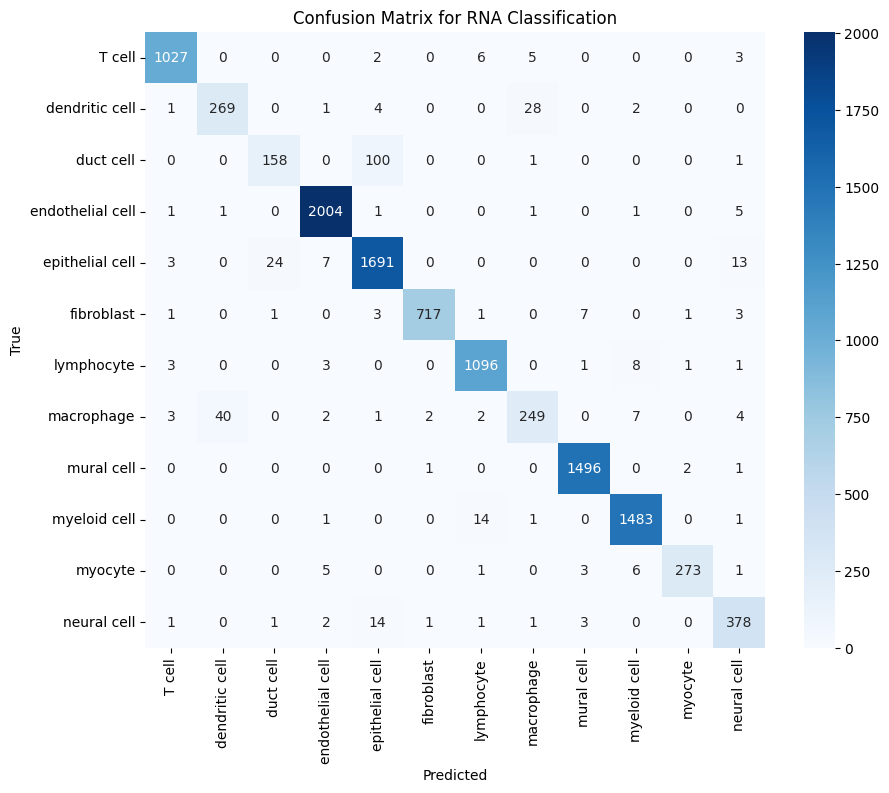

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test_rna.values, y_pred_rna)

# Display confusion matrix as a heatmap
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for RNA Classification')
plt.show()

In [ ]:
y_pred_gex = model_rna.predict(X_test_gex)

# Classification report
print("Classification Report for GEX:")
print(classification_report(y_test_gex.values, y_pred_gex, target_names=label_encoder.classes_))

Classification Report for GEX:
                  precision    recall  f1-score   support

          T cell       0.51      0.34      0.41      1043
  dendritic cell       0.38      0.16      0.23       305
       duct cell       0.71      0.12      0.21       260
endothelial cell       0.82      0.92      0.86      2014
 epithelial cell       0.61      0.67      0.64      1738
      fibroblast       0.68      0.76      0.72       734
      lymphocyte       0.66      0.50      0.56      1113
      macrophage       0.13      0.40      0.19       310
      mural cell       0.94      0.74      0.83      1500
    myeloid cell       0.85      0.04      0.08      1500
         myocyte       0.65      0.78      0.71       289
     neural cell       0.10      0.48      0.16       402

        accuracy                           0.56     11208
       macro avg       0.59      0.49      0.47     11208
    weighted avg       0.69      0.56      0.56     11208



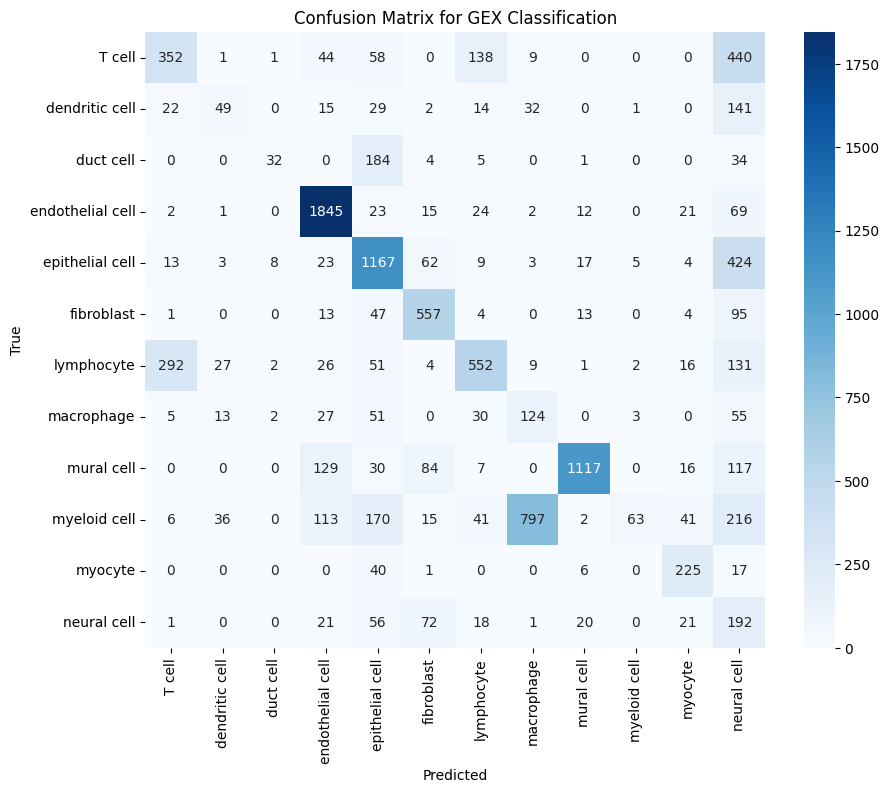

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test_gex.values, y_pred_gex)
# Display confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for GEX Classification')
plt.show()

In [ ]:
y_pred_fake = model_rna.predict(X_test_fake)

# Classification report
print("Classification Report for FAKE:")
print(classification_report(y_test_fake.values, y_pred_fake, target_names=label_encoder.classes_))

Classification Report for FAKE:
                  precision    recall  f1-score   support

          T cell       0.92      0.86      0.89      1043
  dendritic cell       0.91      0.03      0.06       305
       duct cell       0.00      0.00      0.00       260
endothelial cell       1.00      0.89      0.94      2014
 epithelial cell       0.53      1.00      0.70      1738
      fibroblast       0.47      0.97      0.64       734
      lymphocyte       0.95      0.53      0.68      1113
      macrophage       0.14      0.99      0.25       310
      mural cell       1.00      0.44      0.61      1500
    myeloid cell       0.94      0.01      0.02      1500
         myocyte       0.76      0.57      0.65       289
     neural cell       0.00      0.00      0.00       402

        accuracy                           0.61     11208
       macro avg       0.64      0.52      0.45     11208
    weighted avg       0.78      0.61      0.58     11208



/package/python-cbrg/current/3.11.14/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/package/python-cbrg/current/3.11.14/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/package/python-cbrg/current/3.11.14/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

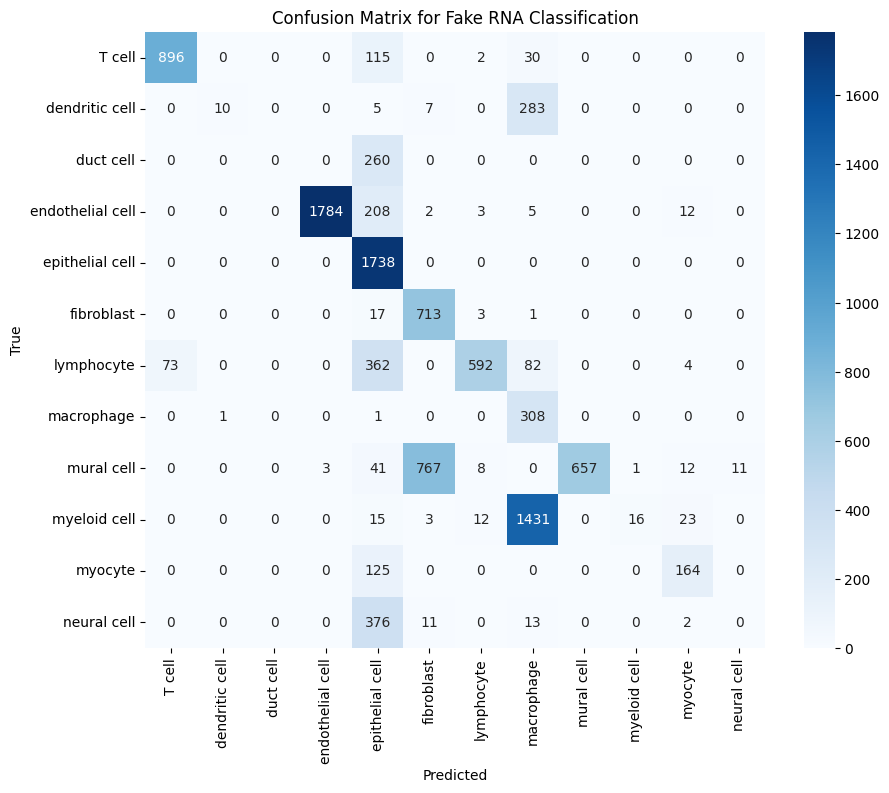

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test_fake.values, y_pred_fake)

# Display confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Fake RNA Classification')
plt.show()


# Fine-tuning on scGEX

In [ ]:
# Load the trained XGBoost model
model_gex = xgb.XGBClassifier()
model_gex.load_model(home + "02_weights/best_xgb_model.json")

In [ ]:
model_gex.fit(X_train_gex, 
              y_train_gex,
              xgb_model=model_gex.get_booster(),  # Continue training from existing model
              verbose=True
              )

[11:02:44] WARNING: ../src/learner.cc:767: 
Parameters: { "device" } are not used.



: 

In [ ]:
y_pred_rna = model_gex.predict(X_test_rna)

# Classification report
print("Classification Report:")
print(classification_report(y_test_rna.values, y_pred_rna, target_names=label_encoder.classes_))

Classification Report:
                  precision    recall  f1-score   support

          T cell       0.99      0.98      0.99      1043
  dendritic cell       0.87      0.88      0.87       305
       duct cell       0.86      0.61      0.71       260
endothelial cell       0.99      1.00      0.99      2014
 epithelial cell       0.93      0.97      0.95      1738
      fibroblast       0.99      0.98      0.99       734
      lymphocyte       0.98      0.98      0.98      1113
      macrophage       0.87      0.80      0.84       310
      mural cell       0.99      1.00      0.99      1500
    myeloid cell       0.98      0.99      0.99      1500
         myocyte       0.99      0.94      0.96       289
     neural cell       0.92      0.94      0.93       402

        accuracy                           0.97     11208
       macro avg       0.95      0.92      0.93     11208
    weighted avg       0.97      0.97      0.97     11208



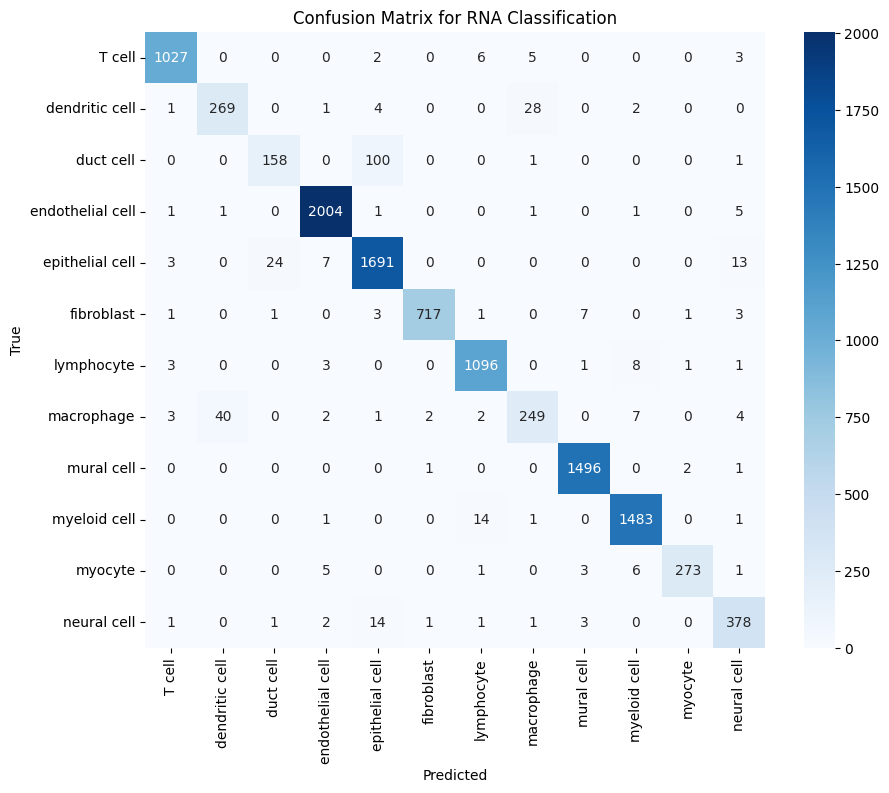

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test_rna.values, y_pred_rna)

# Display confusion matrix as a heatmap
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for RNA Classification')
plt.show()

In [ ]:
y_pred_gex = model_gex.predict(X_test_gex)

# Classification report
print("Classification Report for GEX:")
print(classification_report(y_test_gex.values, y_pred_gex, target_names=label_encoder.classes_))

Classification Report for GEX:
                  precision    recall  f1-score   support

          T cell       0.51      0.34      0.41      1043
  dendritic cell       0.38      0.16      0.23       305
       duct cell       0.71      0.12      0.21       260
endothelial cell       0.82      0.92      0.86      2014
 epithelial cell       0.61      0.67      0.64      1738
      fibroblast       0.68      0.76      0.72       734
      lymphocyte       0.66      0.50      0.56      1113
      macrophage       0.13      0.40      0.19       310
      mural cell       0.94      0.74      0.83      1500
    myeloid cell       0.85      0.04      0.08      1500
         myocyte       0.65      0.78      0.71       289
     neural cell       0.10      0.48      0.16       402

        accuracy                           0.56     11208
       macro avg       0.59      0.49      0.47     11208
    weighted avg       0.69      0.56      0.56     11208



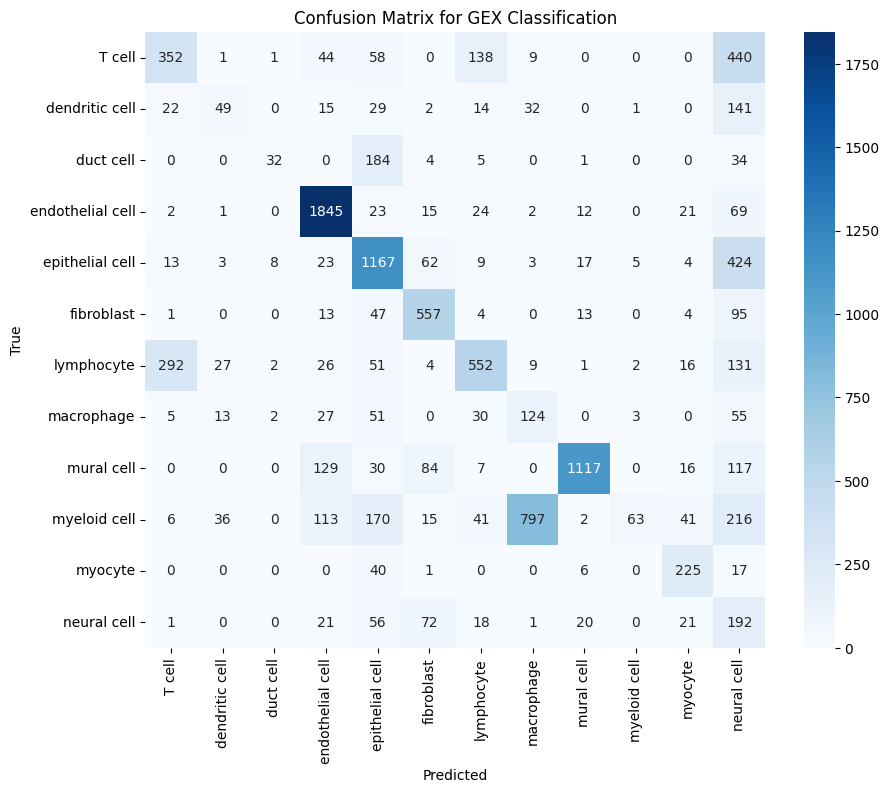

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test_gex.values, y_pred_gex)
# Display confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for GEX Classification')
plt.show()

In [ ]:
y_pred_fake = model_gex.predict(X_test_fake)

# Classification report
print("Classification Report for FAKE:")
print(classification_report(y_test_fake.values, y_pred_fake, target_names=label_encoder.classes_))

Classification Report for FAKE:
                  precision    recall  f1-score   support

          T cell       0.64      1.00      0.78      1043
  dendritic cell       1.00      0.84      0.91       305
       duct cell       1.00      0.11      0.19       260
endothelial cell       0.97      0.98      0.97      2014
 epithelial cell       0.69      1.00      0.82      1738
      fibroblast       0.57      1.00      0.72       734
      lymphocyte       0.99      0.40      0.57      1113
      macrophage       0.17      1.00      0.29       310
      mural cell       1.00      0.66      0.79      1500
    myeloid cell       1.00      0.04      0.07      1500
         myocyte       0.98      0.19      0.32       289
     neural cell       1.00      0.22      0.37       402

        accuracy                           0.69     11208
       macro avg       0.83      0.62      0.57     11208
    weighted avg       0.86      0.69      0.65     11208



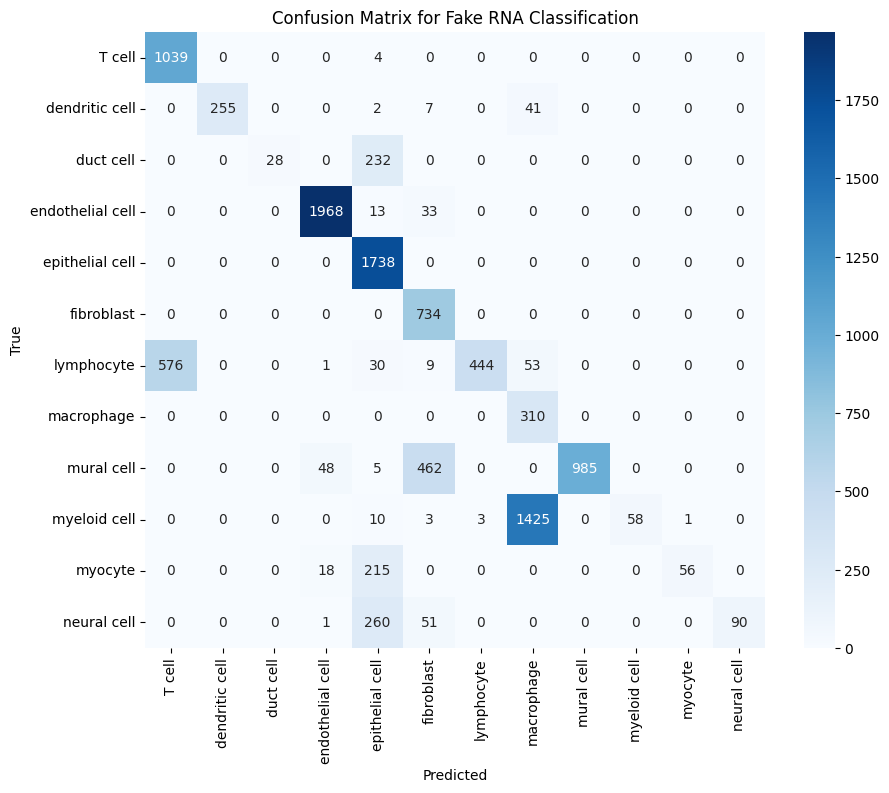

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test_fake.values, y_pred_fake)

# Display confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Fake RNA Classification')
plt.show()


# Fine-tuning on generated scRNA

In [ ]:
# Load the trained XGBoost model
model_fake = xgb.XGBClassifier()
model_fake.load_model(home + "02_weights/best_xgb_model.json")

In [ ]:
model_fake.fit(X_train_fake, 
               y_train_fake,
               xgb_model=model_fake.get_booster(),  # Continue training from existing model
               verbose=True
               )

In [ ]:
y_pred_rna = model_fake.predict(X_test_rna)

# Classification report
print("Classification Report:")
print(classification_report(y_test_rna.values, y_pred_rna, target_names=label_encoder.classes_))

Classification Report:
                  precision    recall  f1-score   support

          T cell       0.99      0.98      0.99      1043
  dendritic cell       0.87      0.88      0.87       305
       duct cell       0.86      0.61      0.71       260
endothelial cell       0.99      1.00      0.99      2014
 epithelial cell       0.93      0.97      0.95      1738
      fibroblast       0.99      0.98      0.99       734
      lymphocyte       0.98      0.98      0.98      1113
      macrophage       0.87      0.80      0.84       310
      mural cell       0.99      1.00      0.99      1500
    myeloid cell       0.98      0.99      0.99      1500
         myocyte       0.99      0.94      0.96       289
     neural cell       0.92      0.94      0.93       402

        accuracy                           0.97     11208
       macro avg       0.95      0.92      0.93     11208
    weighted avg       0.97      0.97      0.97     11208



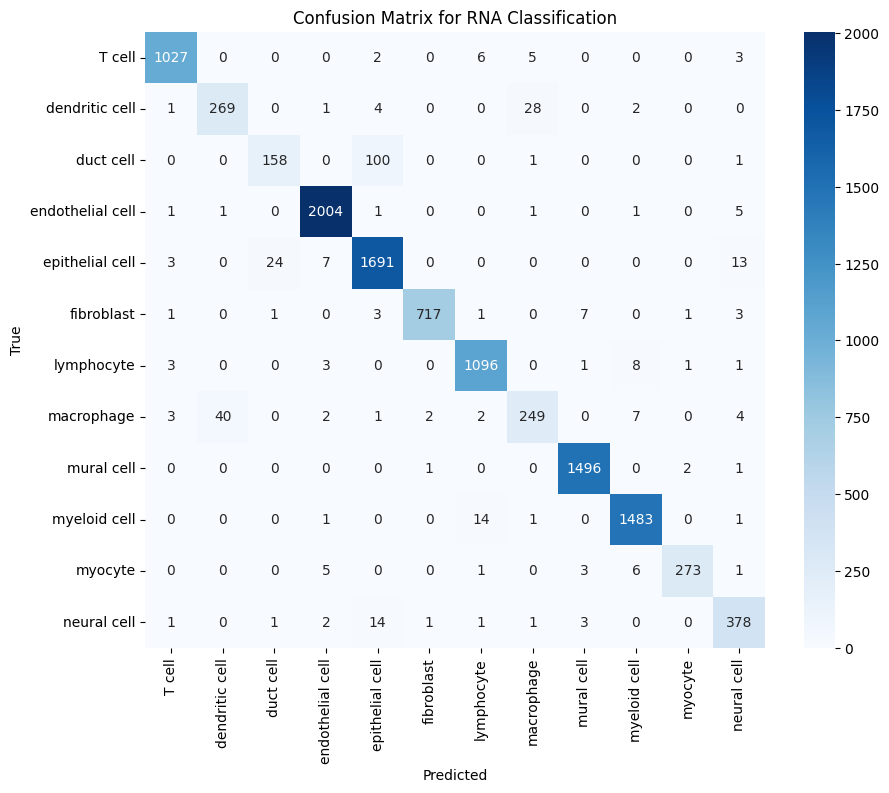

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test_rna.values, y_pred_rna)

# Display confusion matrix as a heatmap
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for RNA Classification')
plt.show()

In [ ]:
y_pred_gex = model_fake.predict(X_test_gex)

# Classification report
print("Classification Report for GEX:")
print(classification_report(y_test_gex.values, y_pred_gex, target_names=label_encoder.classes_))

Classification Report for GEX:
                  precision    recall  f1-score   support

          T cell       0.51      0.34      0.41      1043
  dendritic cell       0.38      0.16      0.23       305
       duct cell       0.71      0.12      0.21       260
endothelial cell       0.82      0.92      0.86      2014
 epithelial cell       0.61      0.67      0.64      1738
      fibroblast       0.68      0.76      0.72       734
      lymphocyte       0.66      0.50      0.56      1113
      macrophage       0.13      0.40      0.19       310
      mural cell       0.94      0.74      0.83      1500
    myeloid cell       0.85      0.04      0.08      1500
         myocyte       0.65      0.78      0.71       289
     neural cell       0.10      0.48      0.16       402

        accuracy                           0.56     11208
       macro avg       0.59      0.49      0.47     11208
    weighted avg       0.69      0.56      0.56     11208



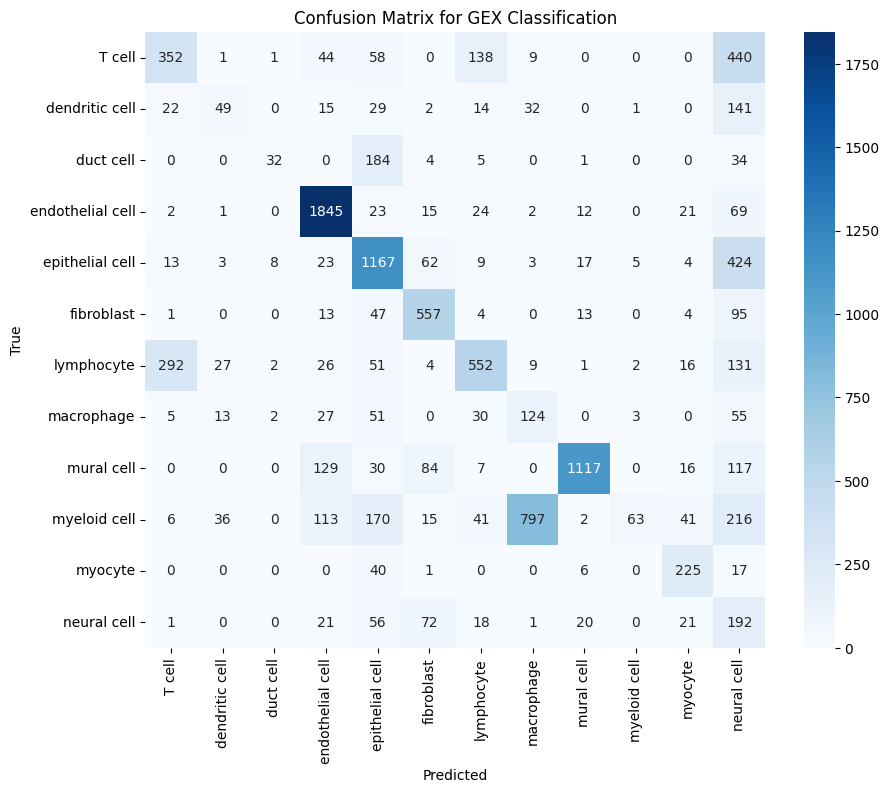

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test_gex.values, y_pred_gex)
# Display confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for GEX Classification')
plt.show()

In [ ]:
y_pred_fake = model_fake.predict(X_test_fake)

# Classification report
print("Classification Report for FAKE:")
print(classification_report(y_test_fake.values, y_pred_fake, target_names=label_encoder.classes_))

Classification Report for FAKE:
                  precision    recall  f1-score   support

          T cell       0.64      1.00      0.78      1043
  dendritic cell       1.00      0.84      0.91       305
       duct cell       1.00      0.11      0.19       260
endothelial cell       0.97      0.98      0.97      2014
 epithelial cell       0.69      1.00      0.82      1738
      fibroblast       0.57      1.00      0.72       734
      lymphocyte       0.99      0.40      0.57      1113
      macrophage       0.17      1.00      0.29       310
      mural cell       1.00      0.66      0.79      1500
    myeloid cell       1.00      0.04      0.07      1500
         myocyte       0.98      0.19      0.32       289
     neural cell       1.00      0.22      0.37       402

        accuracy                           0.69     11208
       macro avg       0.83      0.62      0.57     11208
    weighted avg       0.86      0.69      0.65     11208



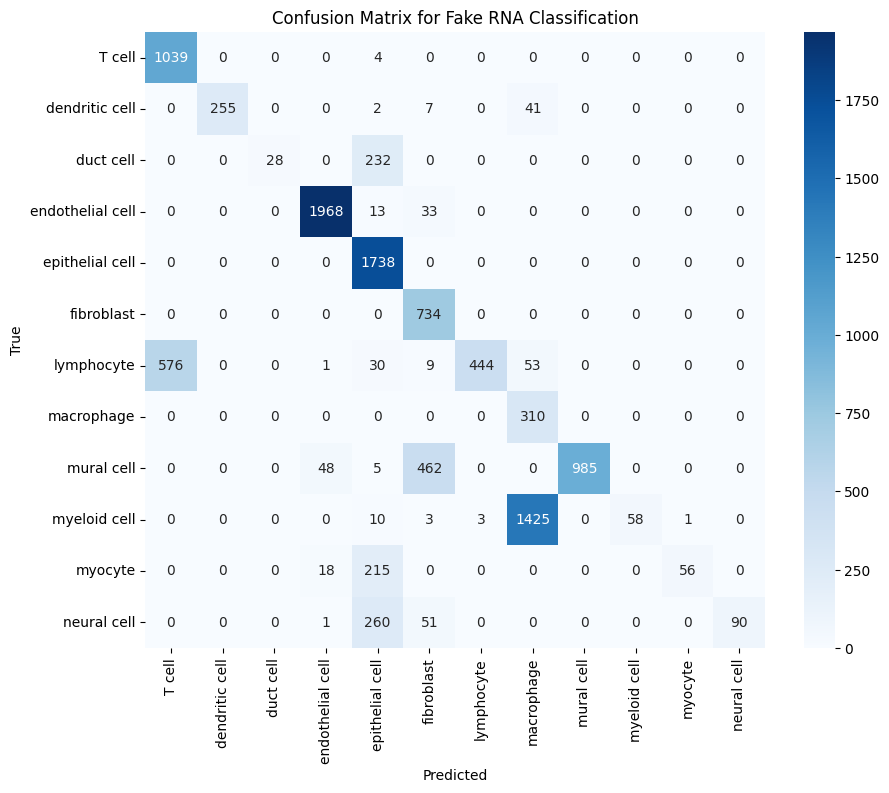

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test_fake.values, y_pred_fake)

# Display confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Fake RNA Classification')
plt.show()


# Classification on BREAST data

In [47]:
# Load breast data
rna = sc.read_h5ad(sriva+"RNA_filt_log_subset.h5ad")
gex = sc.read_h5ad(sriva+"GEX_filt_log_subset.h5ad")
fake = sc.read_h5ad(data+"breast_warmup_fake_PermInv_VAE_UNET.h5ad")

In [48]:
print(rna.X.max(), rna.X.min(), rna.X.mean(), rna.X.std())
print(gex.X.max(), gex.X.min(), gex.X.mean(), gex.X.std())
print(fake.X.max(), fake.X.min(), fake.X.mean(), fake.X.std())

8.371428 0.0 0.07807135 0.36119938
6.7707896 0.0 0.033101026 0.18387508
6.217005 0.0 0.0681654 0.25336692


In [49]:
marker_genes = {'T cell': ['IL7R', 'CCL5', 'PTPRC', 'CXCR4', 'GNLY', 'CD2', 'SRGN'],
                'basal cell': ['KRT14', 'KRT17', 'DST', 'KRT5', 'SAA1', 'ACTA2', 'SFN'],
                'endothelial cell': ['SELE', 'ACKR1', 'FABP4', 'STC1', 'ANGPT2', 'CSF3'],
                'fibroblast': ['DCN', 'APOD', 'CFD', 'TNFAIP6', 'LUM', 'COL1A2', 'COL1A1'],
                'macrophage': ['HLA-DRA', 'IL1B', 'HLA-DPA1', 'HLA-DPB1', 'HLA-DRB1', 'CD74', 'CCL3']
              }

In [50]:
genes = []

for row in list(marker_genes.values()):
    for item in row:
        if item not in genes:
            genes.append(item)
            
# np.random.shuffle(genes)

In [51]:
df_rna = pd.DataFrame(index   = rna.obs.index,
                      columns = genes,
                      data    = rna.X[:, rna.var.feature_name.isin(genes)])

df_gex = pd.DataFrame(index   = gex.obs.index,
                      columns = genes,
                      data    = gex.X[:, gex.var.feature_name.isin(genes)])

df_fake = pd.DataFrame(index   = fake.obs.index,
                       columns = genes,
                       data    = fake.X[:, fake.var.feature_name.isin(genes)])

In [52]:
# Encode labels
label_encoder = LabelEncoder()
label_encoder.fit(rna.obs["cell_type"].values.tolist())
label_encoder.classes_

array(['T cell', 'basal cell', 'endothelial cell', 'fibroblast',
       'macrophage'], dtype='<U16')

In [53]:
df_rna["cell_type"]  = label_encoder.transform(rna.obs["cell_type"].values.tolist())
df_gex["cell_type"]  = label_encoder.transform(gex.obs["cell_type"].values.tolist())
df_fake["cell_type"] = label_encoder.transform(rna.obs["cell_type"].values.tolist())

In [54]:
# Create train-test split (final evaluation set)
X_train_rna, X_test_rna, y_train_rna, y_test_rna = train_test_split(df_rna[df_rna.columns[:-1]],
                                                                    df_rna[df_rna.columns[-1]],
                                                                    test_size=0.15,
                                                                    random_state=42,
                                                                    stratify=df_rna[df_rna.columns[-1]]
                                                                    )

In [55]:
# Create train-test split (final evaluation set)
X_train_gex, X_test_gex, y_train_gex, y_test_gex = train_test_split(df_gex[df_gex.columns[:-1]],
                                                                    df_gex[df_gex.columns[-1]],
                                                                    test_size=0.15,
                                                                    random_state=42,
                                                                    stratify=df_gex[df_gex.columns[-1]]
                                                                    )

In [56]:
# Create train-test split (final evaluation set)
X_train_fake, X_test_fake, y_train_fake, y_test_fake = train_test_split(df_fake[df_fake.columns[:-1]],
                                                                        df_fake[df_fake.columns[-1]],
                                                                        test_size=0.15,
                                                                        random_state=42,
                                                                        stratify=df_fake[df_fake.columns[-1]]
                                                                        )

# Performance evaluation on scRNA, scGEX, generated scGEX

In [57]:
model_rna = xgb.XGBClassifier()
model_rna.load_model(home + "02_weights/breast_best_xgb_model.json")

In [58]:
# y_pred_rna = model_rna.predict(X_train_rna)
# print(f'Accuracy: {accuracy_score(y_train_rna.values, y_pred_rna):.4f}')

In [59]:
y_pred_rna = model_rna.predict(X_test_rna)

# Classification report
print("Classification Report:")
print(classification_report(y_test_rna.values, y_pred_rna, target_names=label_encoder.classes_))

Classification Report:
                  precision    recall  f1-score   support

          T cell       1.00      0.99      1.00       336
      basal cell       1.00      1.00      1.00      2428
endothelial cell       1.00      1.00      1.00       811
      fibroblast       1.00      1.00      1.00       979
      macrophage       0.99      0.99      0.99       194

        accuracy                           1.00      4748
       macro avg       1.00      1.00      1.00      4748
    weighted avg       1.00      1.00      1.00      4748



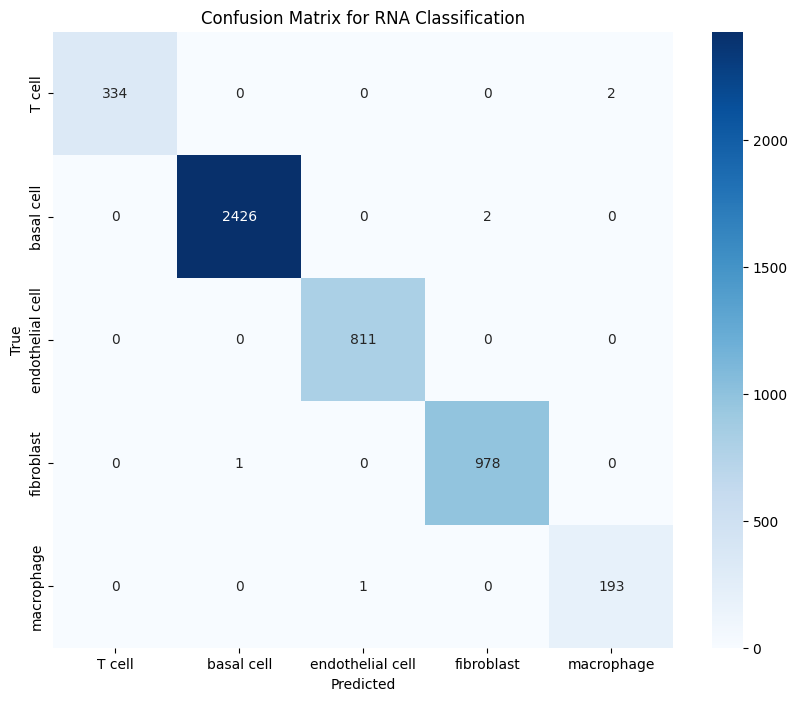

In [60]:
# Confusion matrix
cm = confusion_matrix(y_test_rna.values, y_pred_rna)

# Display confusion matrix as a heatmap
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for RNA Classification')
plt.show()

In [61]:
y_pred_gex = model_rna.predict(X_test_gex)

# Classification report
print("Classification Report for GEX:")
print(classification_report(y_test_gex.values, y_pred_gex, target_names=label_encoder.classes_))

Classification Report for GEX:
                  precision    recall  f1-score   support

          T cell       0.93      0.41      0.57       336
      basal cell       0.83      0.58      0.68      2428
endothelial cell       0.67      0.21      0.32       811
      fibroblast       0.97      0.31      0.47       979
      macrophage       0.07      0.87      0.13       194

        accuracy                           0.46      4748
       macro avg       0.70      0.48      0.44      4748
    weighted avg       0.81      0.46      0.55      4748



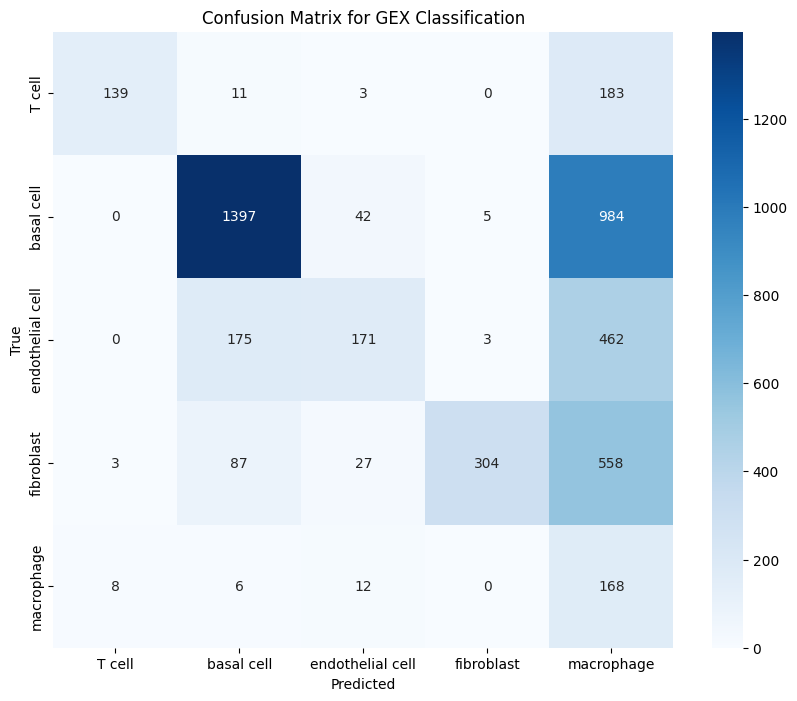

In [62]:
# Confusion matrix
cm = confusion_matrix(y_test_gex.values, y_pred_gex)
# Display confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for GEX Classification')
plt.show()

In [63]:
y_pred_fake = model_rna.predict(X_test_fake)

# Classification report
print("Classification Report for FAKE:")
print(classification_report(y_test_fake.values, y_pred_fake, target_names=label_encoder.classes_))

Classification Report for FAKE:
                  precision    recall  f1-score   support

          T cell       0.00      0.00      0.00       336
      basal cell       0.51      1.00      0.68      2428
endothelial cell       0.12      0.00      0.01       811
      fibroblast       0.00      0.00      0.00       979
      macrophage       0.00      0.00      0.00       194

        accuracy                           0.51      4748
       macro avg       0.13      0.20      0.14      4748
    weighted avg       0.28      0.51      0.35      4748



/package/python-cbrg/current/3.11.14/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/package/python-cbrg/current/3.11.14/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/package/python-cbrg/current/3.11.14/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

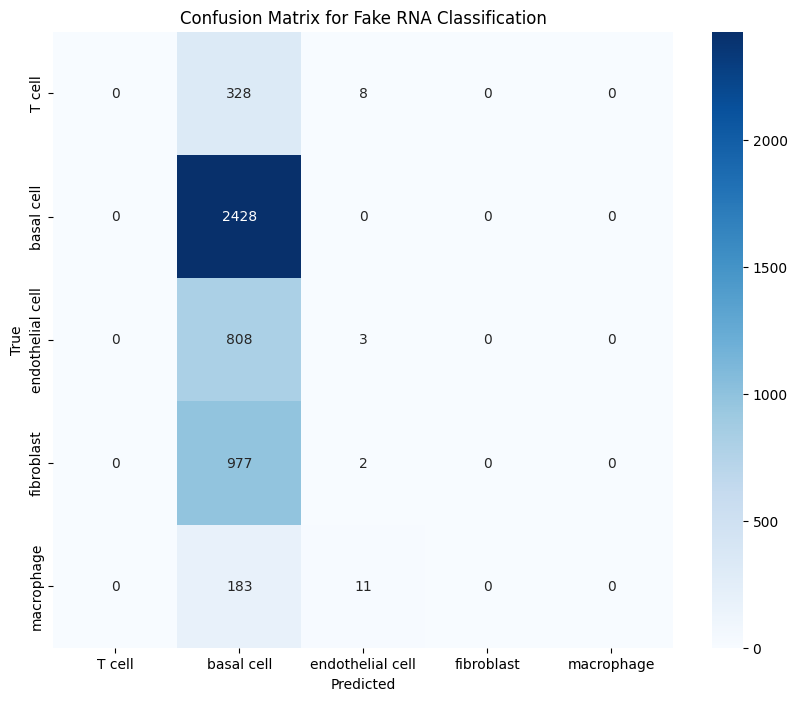

In [64]:
# Confusion matrix
cm = confusion_matrix(y_test_fake.values, y_pred_fake)

# Display confusion matrix as a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix for Fake RNA Classification')
plt.show()


## Analyse fake data

In [21]:
import numpy as np
import pandas as pd
import scipy.sparse as sp

# Edit these for your dataset's naming (gene symbols expected here)
MARKERS = {
    "T cell": ['IL7R', 'CCL5', 'PTPRC', 'CXCR4', 'GNLY', 'CD2', 'SRGN'],
    "macrophage": ['HLA-DRA', 'IL1B', 'HLA-DPA1', 'HLA-DPB1', 'HLA-DRB1', 'CD74', 'CCL3'],
    "endothelial cell": ['SELE', 'ACKR1', 'FABP4', 'STC1', 'ANGPT2', 'CSF3'],
    "fibroblast": ['DCN', 'APOD', 'CFD', 'TNFAIP6', 'LUM', 'COL1A2', 'COL1A1'],
    "basal cell": ['KRT14', 'KRT17', 'DST', 'KRT5', 'SAA1', 'ACTA2', 'SFN'],
}

GENES = sorted(set(g for gs in MARKERS.values() for g in gs))

In [22]:
def build_feature_index(adata, feature_col="feature_name"):
    """
    Returns dict: feature_name -> column index in adata.X
    If duplicates exist, keeps the first occurrence.
    """
    if feature_col not in adata.var.columns:
        raise KeyError(f"{feature_col} not found in adata.var.columns")

    feats = adata.var[feature_col].astype(str).values
    feat_to_idx = {}
    for j, f in enumerate(feats):
        if f not in feat_to_idx:
            feat_to_idx[f] = j
    return feat_to_idx


def _get_X_col_by_feature(adata, feature, feat_to_idx):
    """Return (n_cells,) vector for a single feature_name, handling sparse."""
    j = feat_to_idx.get(feature, None)
    if j is None:
        return None
    col = adata.X[:, j]
    if sp.issparse(col):
        col = col.toarray().ravel()
    else:
        col = np.asarray(col).ravel()
    return col.astype(np.float32)


def mean_by_cell_type_feature(adata, genes, cell_type_key="cell_type", feature_col="feature_name"):
    """
    genes: list of gene symbols that match adata.var[feature_col]
    Returns df: index=cell_type, columns=genes, values=mean expression.
    """
    if cell_type_key not in adata.obs.columns:
        raise KeyError(f"{cell_type_key} not found in adata.obs")

    feat_to_idx = build_feature_index(adata, feature_col=feature_col)

    cell_types = adata.obs[cell_type_key].astype(str).values
    uniq_ct = pd.Index(sorted(pd.unique(cell_types)), name="cell_type")

    out = pd.DataFrame(index=uniq_ct, columns=genes, dtype=np.float32)

    for g in genes:
        x = _get_X_col_by_feature(adata, g, feat_to_idx)
        if x is None:
            out[g] = np.nan
            continue
        for ct in uniq_ct:
            mask = (cell_types == ct)
            out.loc[ct, g] = float(x[mask].mean()) if mask.sum() else np.nan

    return out

In [23]:
# ---- run comparison ----
cell_type_key = "cell_type"        # change if needed
feature_col = "feature_name"       # as you said

real_means = mean_by_cell_type_feature(rna, GENES, cell_type_key=cell_type_key, feature_col=feature_col)
fake_means = mean_by_cell_type_feature(fake, GENES, cell_type_key=cell_type_key, feature_col=feature_col)

comparison = real_means.add_suffix("_real").join(fake_means.add_suffix("_fake"))

pseudocount = 1e-3
for g in GENES:
    comparison[f"{g}_logFC(fake/real)"] = np.log2(
        (comparison[f"{g}_fake"] + pseudocount) / (comparison[f"{g}_real"] + pseudocount)
    )

comparison

,ACKR1_real,ACTA2_real,ANGPT2_real,APOD_real,CCL3_real,CCL5_real,CD2_real,CD74_real,CFD_real,COL1A1_real,...,KRT17_logFC(fake/real),KRT5_logFC(fake/real),LUM_logFC(fake/real),PTPRC_logFC(fake/real),SAA1_logFC(fake/real),SELE_logFC(fake/real),SFN_logFC(fake/real),SRGN_logFC(fake/real),STC1_logFC(fake/real),TNFAIP6_logFC(fake/real)
cell_type,,,,,,,,,,,,,,,,,,,,,
T cell,0.028600,0.089374,0.041328,0.310177,0.098835,1.919498,1.524930,0.581080,0.267487,0.086228,...,3.000261,3.952577,3.183844,-11.348921,2.712151,4.570127,3.521481,-1.563730,4.150496,3.828139
basal cell,0.025471,2.833364,0.029147,0.413146,0.014262,0.006152,0.001374,0.401789,0.176594,0.100154,...,-1.021538,-0.903865,2.970710,-3.054599,-0.906349,4.022023,-0.928442,2.846193,3.068242,3.201101
endothelial cell,2.854468,0.053634,1.717566,0.460737,0.015387,0.015411,0.002337,2.681693,0.174494,0.053590,...,2.990618,4.551466,3.805846,-3.403469,2.947998,-1.288585,3.999960,-0.591623,-1.420722,3.907143
fibroblast,0.022160,0.223124,0.054643,3.556995,0.064418,0.013826,0.001480,0.134666,2.823058,1.672419,...,3.261968,4.474583,-1.175669,-3.566953,2.780253,4.413327,4.455735,1.839638,2.871871,-1.108060
macrophage,0.018764,0.048006,0.027664,0.223752,1.205008,0.109074,0.025457,3.332571,1.192605,0.055266,...,4.791831,5.646800,3.154853,-10.013616,3.118976,4.760341,5.625597,-1.497136,3.655051,1.863266


In [24]:
import numpy as np
import pandas as pd

# genes you want to compare (use the same list you used to build the means)
genes = GENES  # or your custom list

ct = "macrophage"  # pick a cell type to inspect first (or loop over all)

rows = []
pseudocount = 1e-3
for g in genes:
    r = comparison.loc[ct, f"{g}_real"] if f"{g}_real" in comparison.columns else np.nan
    f = comparison.loc[ct, f"{g}_fake"] if f"{g}_fake" in comparison.columns else np.nan
    rows.append({
        "gene": g,
        "real_mean": r,
        "fake_mean": f,
        "fake/real": (f + pseudocount) / (r + pseudocount),
        "log2FC(fake/real)": np.log2((f + pseudocount) / (r + pseudocount)),
        "abs_diff": f - r,
    })

df_ct = pd.DataFrame(rows).sort_values("log2FC(fake/real)")
df_ct

,gene,real_mean,fake_mean,fake/real,log2FC(fake/real),abs_diff
4,CCL3,1.205008,0.000000,0.000829,-10.236023,-1.205008
27,PTPRC,1.032710,0.000000,0.000967,-10.013616,-1.032710
21,IL1B,0.768732,0.000000,0.001299,-9.588213,-0.768732
12,CXCR4,0.710770,0.000000,0.001405,-9.475268,-0.710770
6,CD2,0.025457,0.000000,0.037797,-4.725589,-0.025457
16,GNLY,0.007559,0.000000,0.116833,-3.097482,-0.007559
19,HLA-DRA,3.527543,0.969982,0.275179,-1.861556,-2.557561
17,HLA-DPA1,2.476748,0.734783,0.296956,-1.751677,-1.741965
18,HLA-DPB1,2.382893,0.716899,0.301146,-1.731467,-1.665994
20,HLA-DRB1,2.759755,0.869905,0.315459,-1.664476,-1.889850


In [25]:
# how many markers found?
feat_real = set(rna.var[feature_col].astype(str).values)
feat_fake = set(fake.var[feature_col].astype(str).values)

print("Markers missing in REAL:", [g for g in GENES if g not in feat_real])
print("Markers missing in FAKE:", [g for g in GENES if g not in feat_fake])

# duplicate feature_name check
dup_real = rna.var[feature_col].astype(str).duplicated().sum()
dup_fake = fake.var[feature_col].astype(str).duplicated().sum()
print("Duplicate feature_name count (real):", int(dup_real))
print("Duplicate feature_name count (fake):", int(dup_fake))

Markers missing in REAL: []
Markers missing in FAKE: []
Duplicate feature_name count (real): 0
Duplicate feature_name count (fake): 0


For each cell type, compute mean expression in fake vs real for canonical markers:
T cell: PTPRC, CD2, TRAC, LTB, IL7R, NKG7/GNLY (depending on your atlas)
Macrophage: LYZ, C1QA/B/C, FCGR3A, LST1, TYROBP, HLA-DRA
If these are near-zero or not enriched in the right group in fake, XGB will never predict those classes

In [26]:
# Compute what is written above for each marker gene, to see if the model is missing key signals in the fake data that it relies on in the real data.
